In [ ]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
import anndata as ad
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [8]:
data_test='Jaspar26'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/'

In [9]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
# df_tbffile = pd.read_csv(tbffile, sep='\t')

In [10]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass']
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if ('FDR' not in results.columns) and ('MC_MW_pvalue' in results.columns):
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results


In [11]:
# df = df_tbffile
# motif_similarity_fdr = 0.001,
# orthologous_identity_threshold  = 0.0
# df.rename(columns={'#motif_id':"MotifID",
#                     'gene_name':"TF",
#                     'motif_similarity_qvalue': "MotifSimilarityQvalue",
#                     'orthologous_identity': "OrthologousIdentity",
#                     'description': "Annotation" }, inplace=True)
# df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
#         (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [12]:
# df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
# #df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

# df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
# df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
# df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
# dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
# motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
# #motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

# direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
# direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [13]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [14]:
# extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
# extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [15]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_results.xlsx')

In [16]:
TOBIAS_Rsults

['/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_Microglia-2_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_AMY_Ndnf_Lamp5_GABA_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_AMY_Ccdc3_Acvr1c_Glut_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_AMY_Zfhx3_Glra1_Glut_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_MFOL_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_AMY_Maf_Pthlh_GABA_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_OPC_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_Jaspar26/AMY_AMY_Tcf7l2_Gm20713_Glut_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/AMY_J

In [17]:
TOBIAS_distances = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_distances.txt')

In [18]:
def calculate_medoids(D, labels):
    """
    Calculate the medoid for each cluster based on a precomputed distance matrix.

    Parameters:
    D (numpy.ndarray): A square symmetric matrix of pairwise distances.
    labels (numpy.ndarray): An array of cluster labels for each point.

    Returns:
    dict: A dictionary where keys are cluster labels and values are the indices of the medoids.
    """
    unique_labels = np.unique(labels)
    medoids = {}
    
    for k in unique_labels:
        # 1. Get indices of points in the current cluster
        cluster_indices = np.where(labels == k)[0]
        
        # 2. Extract the sub-distance matrix for the current cluster
        cluster_distance_matrix = D[np.ix_(cluster_indices, cluster_indices)]
        
        # 3. Calculate the sum of distances for each point in the cluster
        sum_of_distances = np.sum(cluster_distance_matrix, axis=1)
        
        # 4. Find the index of the point with the minimum sum of distances *within the cluster*
        medoid_index_in_cluster = np.argmin(sum_of_distances)
        
        # 5. Map this index back to the original global index
        global_medoid_index = cluster_indices[medoid_index_in_cluster]
        
        medoids[k] = global_medoid_index
        
    return medoids

def get_motif_medoids(df_distance,method='average',threshold=0.5):
    linkage_mat = linkage(squareform(df_distance), method)
    labels = fcluster(linkage_mat, threshold, criterion="distance")		#ordering of the dendrogram
    dict_motif_clusters = dict(zip(df_distance.columns,labels))
    dict_cluster_mot = calculate_medoids(df_distance.values,labels)
    dict_cluster_name = {}
    for key in dict_cluster_mot.keys():
        dict_cluster_name[key] = df_distance.columns[dict_cluster_mot[key]]
    dit_motif_to_medoid = {}
    for key in dict_motif_clusters.keys():
        dit_motif_to_medoid[key] = dict_cluster_name[dict_motif_clusters[key]]
    return dit_motif_to_medoid


# Merge all TOBIAS results on TF level

In [19]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    #df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = 'Jaspar26'
    #df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    #df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()

    distance_file = file.replace('bindetect_results.xlsx','bindetect_distances.txt')
    df_distance = pd.read_csv(distance_file,sep='\t')
    df_distance.index = df_distance.columns
    motif2medoids = get_motif_medoids(df_distance)

    df_tobias['motifmedoid'] = df_tobias['output_prefix'].map(motif2medoids).values
    #df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    full_results = pd.concat([full_results, df_tobias], axis=0)
    #results = pd.concat([results, df_expanded_mean], axis=0)



In [20]:
full_results['TF'] = full_results['name']

In [ ]:
# export to matrix
cell_type_matrix = f"/data2st1/junyi/output/atac1112/tobias/tobias_matrix/{data_test}"
if not os.path.exists(cell_type_matrix):
    os.makedirs(cell_type_matrix)

In [121]:
full_results.to_csv(os.path.join(cell_type_matrix, f'{data_test}_tobias_full_results.csv'), index=False)

full_results

/tmp/ipykernel_4135808/3290138997.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_ADD['nlogp'] = -np.log10(full_results_ADD['FDR'] + 1e-300) * np.sign(full_results_ADD['log2FC'])
/tmp/ipykernel_4135808/3290138997.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_ADD['Regulation'] = full_results_ADD['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_4135808/3290138997.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


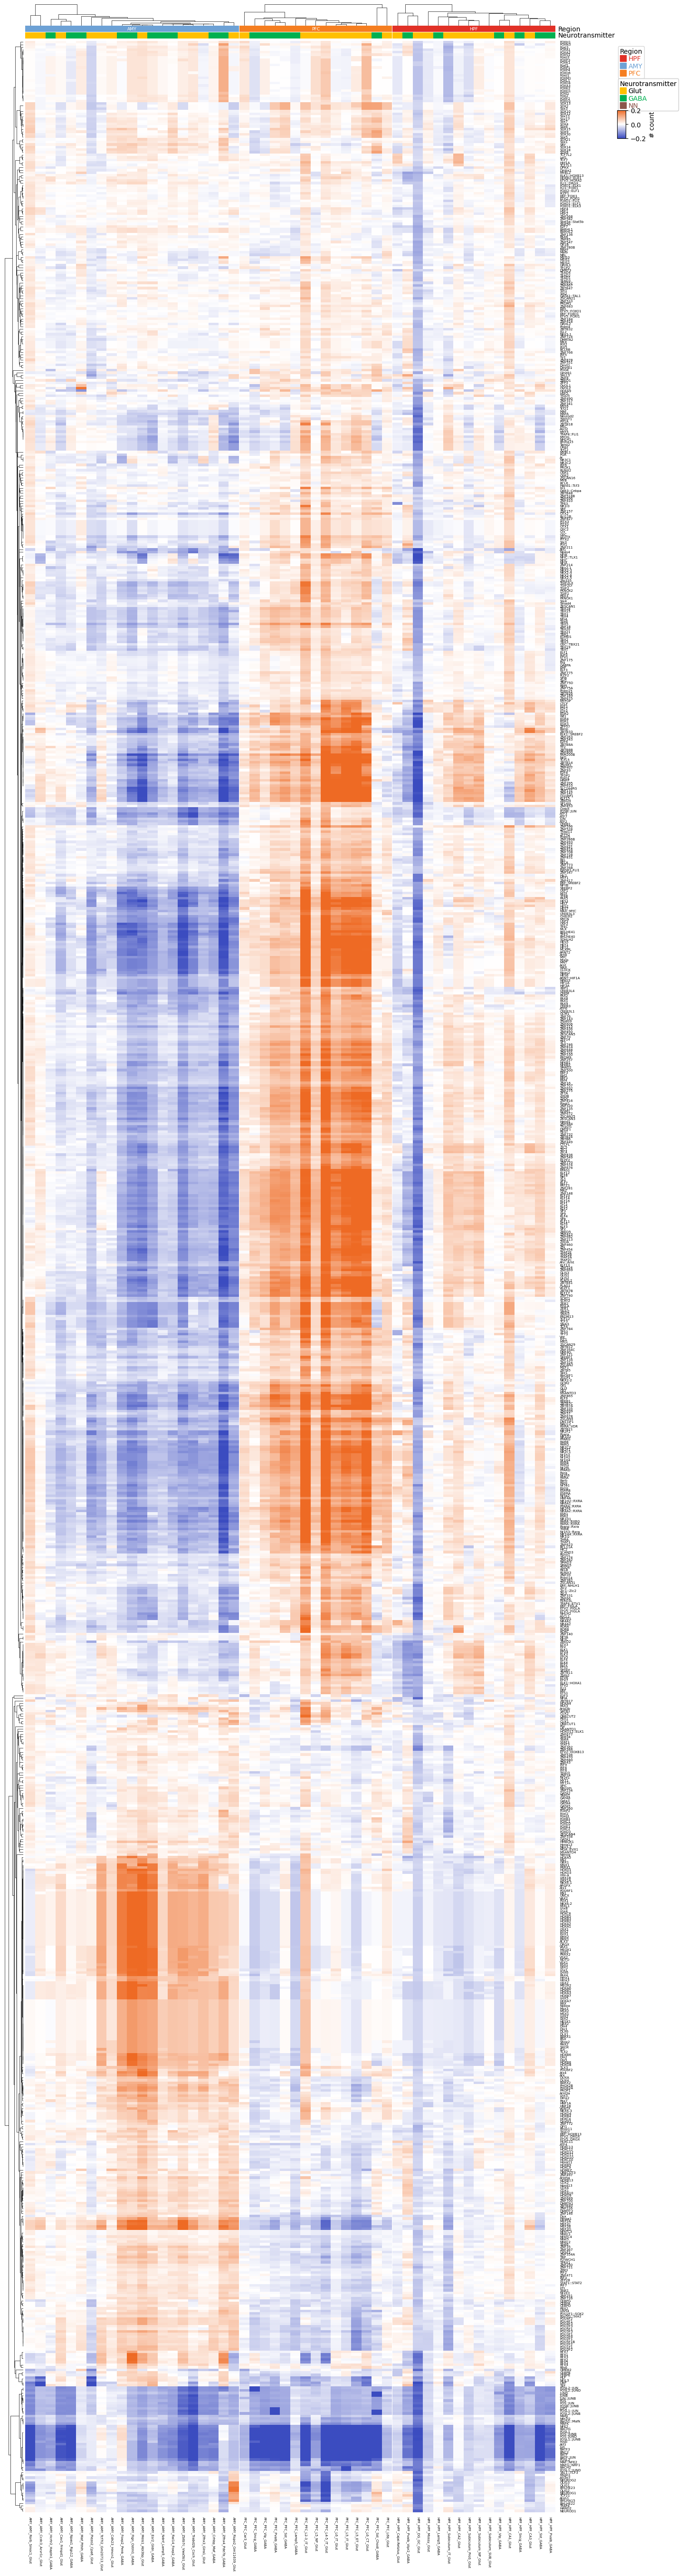

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:1836: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  col_clusters = self.col_split.groupby(cols).apply(
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/p

Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


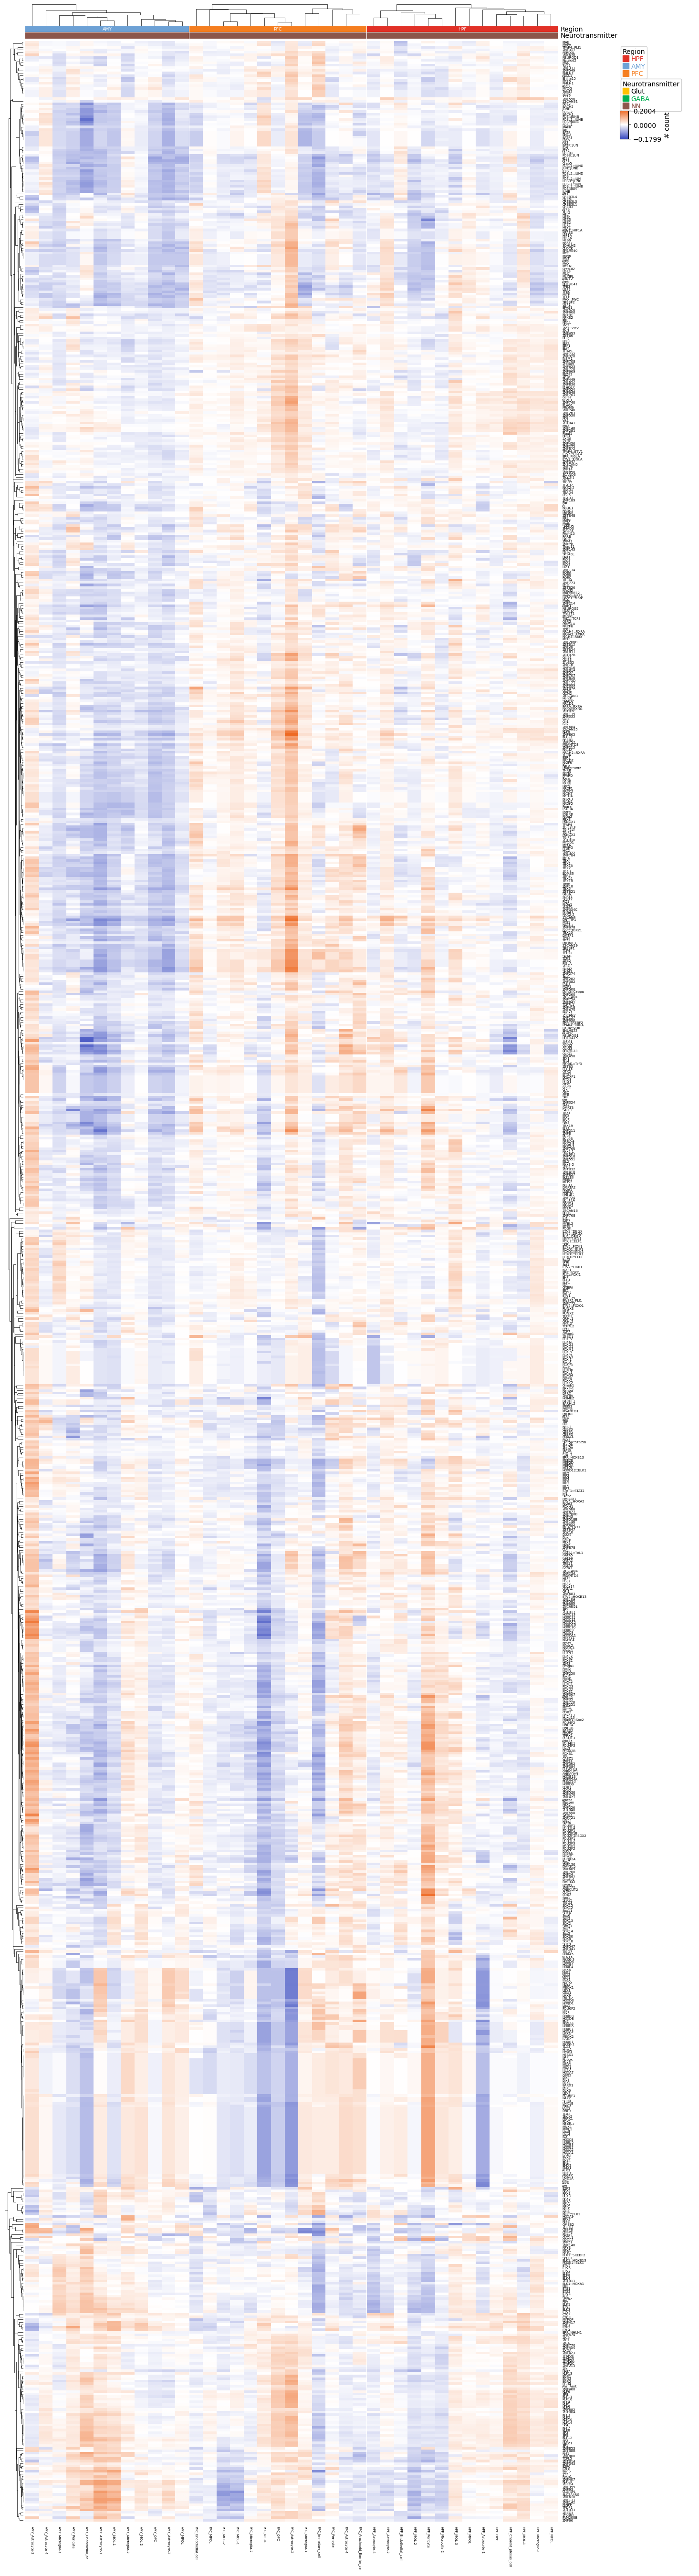

PermissionError: [Errno 13] Permission denied: '/data2st1/junyi/output/atac1112/tobias/BIND_sub_mat_FULL_Jaspar26.csv'

In [118]:
full_results_ADD = add_columns(full_results)
full_results_ADD=full_results_ADD[full_results_ADD.FDR < 0.05]
full_results_ADD['nlogp'] = -np.log10(full_results_ADD['FDR'] + 1e-300) * np.sign(full_results_ADD['log2FC'])
full_results_ADD['Regulation'] = full_results_ADD['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
full_results_ADD['Regulation']=full_results_ADD['Regulation'].astype(float)
cm = draw_tf_heatmap(full_results_ADD[full_results_ADD.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,60)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_sub_FULL_{data_test}.pdf')
cmNN = draw_tf_heatmap(full_results_ADD[full_results_ADD.Neurotransmitter=='NN'],figure_size=(15,60),value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_sub_FULL_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_sub_mat_FULL_{data_test}.csv')


In [ ]:
full_results_ADD.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_filtered_full_results_{data_test}.csv',index=False)

In [ ]:
full_results_ADD

In [ ]:
full_results_sub=full_results_ADD[full_results_ADD.output_prefix==full_results_ADD.motifmedoid]

In [ ]:
full_results_sub=full_results_sub[full_results_sub.abs_change>0.05]

In [ ]:
cm = draw_tf_heatmap(full_results_sub[full_results_sub.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,60)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_sub_FULL_{data_test}.pdf')
cmNN = draw_tf_heatmap(full_results_sub[full_results_sub.Neurotransmitter=='NN'],figure_size=(15,60),value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_sub_FULL_{data_test}.pdf')


In [ ]:
full_results_back = full_results.copy()

In [ ]:
full_results = full_results_sub

In [38]:
import anndata as ad
import scanpy as sc

In [ ]:
def build_tobias_adata(df, condition='MC'):
    value_col = f'{condition}_bound'
    score_col = f'{condition}_mean_score'
    required_cols = ['ctname', 'TF', value_col, score_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f'Missing columns: {missing_cols}')

    matrix_df = df[required_cols].copy()
    matrix_df = matrix_df.groupby(['ctname', 'TF'], as_index=False).mean(numeric_only=True)

    bound_matrix = matrix_df.pivot(index='ctname', columns='TF', values=value_col).fillna(0)
    score_matrix = matrix_df.pivot(index='ctname', columns='TF', values=score_col)
    score_matrix = score_matrix.reindex(index=bound_matrix.index, columns=bound_matrix.columns).fillna(0)

    adata = ad.AnnData(X=bound_matrix.to_numpy())
    adata.obs_names = bound_matrix.index.astype(str)
    adata.var_names = bound_matrix.columns.astype(str)
    #adata.obs.index.name = 'Region Subclass'
    adata.obs['Region Subclass'] = adata.obs_names
    adata.obs['condition'] = condition
    adata.layers['mean_score'] = score_matrix.to_numpy()
    return adata


AnnData object with n_obs × n_vars = 91 × 964
    obs: 'Region Subclass', 'condition'
    layers: 'mean_score'

In [115]:
if not os.path.exists( f'/data2st1/junyi/output/atac1112/tobias/tobias_matrix/{data_test}/tobiasmatrix.h5ad'):
    adata_mc = build_tobias_adata(full_results, condition='MC')
    adata_mw = build_tobias_adata(full_results, condition='MW')
    adata_tobias = ad.concat([adata_mc, adata_mw], axis=0)
    adata_tobias.layers['bound'] = adata_tobias.X.copy()
    sc.pp.normalize_per_cell(adata_tobias)
    sc.pp.log1p(adata_tobias)
    adata_tobias.obs['region'] = adata_tobias.obs['Region Subclass'].str[:3].str.replace('HIP','HPF')
    sc.tl.pca(adata_tobias, n_comps=50)
    sc.pp.neighbors(adata_tobias, use_rep='X_pca')
    sc.tl.umap(adata_tobias, min_dist=0.5)
    sc.pl.pca(adata_tobias, color='region')
    sc.tl.rank_genes_groups(adata_tobias, groupby='condition', method='wilcoxon')
    adata_tobias.write_h5ad(
        f'/data2st1/junyi/output/atac1112/tobias/tobias_matrix/{data_test}/tobiasmatrix.h5ad'
    )

In [ ]:
logfiles =[
'/home/junyichen/logs/17binplotAGG.sh.2026-01-05-16-05-40.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-04-10-35-26.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-02-17-38-29.out',
]

In [ ]:
# specific_word = '[STATS]	FPD ('
# lines = []
# remove_chars = "[]();\t:"
# for logfile in logfiles:
#     with open(logfile, 'r') as infile:
#         filtered_lines = list(map(str.strip, filter(lambda line: specific_word in line, infile)))
#     lines+=filtered_lines

In [ ]:
specific_word = '[STATS]\tFPD ('
lines = []

remove_chars = "[]();\t:"
table = str.maketrans("", "", remove_chars)

for logfile in logfiles:
    with open(logfile, "r") as infile:
        filtered_lines = [
            line.translate(table).replace(",", " ").strip()
            for line in infile
            if specific_word in line
        ]
    lines += filtered_lines


In [ ]:
rows = [ln.split() for ln in lines]

df = pd.DataFrame(rows)


In [ ]:
df_score=df.iloc[:,4:]

In [ ]:
df_score.columns=['celltype','motif','width','bgscore','midscore','tfbsscore']

In [ ]:
df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")
df_score['Condtion']=df_score['Region Subclass Condition'].str.split("_").str[-1]
df_score['Region Subclass'] = df_score['Region Subclass Condition'].str[:-3]
df_score['Region Subclass'] = df_score['Region Subclass'].str.replace("HIP","HPF")
df_score['motif'] = df_score['motif'].str.replace("_all","")

In [ ]:
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('HPF_HPF',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('AMY_AMY',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('PFC_PFC',"")

In [ ]:
full_results_sub = add_columns(full_results_sub)

In [ ]:
df_merge = pd.merge(df_score,full_results_sub,how='right',left_on=['Region Subclass','motif'],right_on=['Region Subclass','motifmedoid'])

In [ ]:
df_merge['bgscore'] = df_merge['bgscore'].astype(float)
df_merge['midscore'] = df_merge['midscore'].astype(float)
df_merge['tfbsscore'] = df_merge['tfbsscore'].astype(float)
df_merge['width'] = df_merge['width'].astype(float)

In [ ]:
df_merge.tfbsscore.var()

In [ ]:
for interval in [(0,20)]:
    df_interval = df_merge[(df_merge.width>=interval[0]) & (df_merge.width<=interval[1])]
    tfbsscore_var = df_interval.tfbsscore.var()
    tfbsscore_median = df_interval.tfbsscore.median()
    # df_interval['valid'] = df_interval.tfbsscore<0
    # df_interval['sum'] =    1
    # df_interval_count = df_interval.groupby(['Region Subclass','Condtion','motif']).sum().reset_index()
    # df_interval_var = df_interval.groupby(['Region Subclass','Condtion','motif']).var().reset_index()
    # df_interval_count['valid_pct'] = df_interval_count['valid'] / df_interval_count['sum']
    # num_pass = df_interval_count[df_interval_count.valid_pct>=0.8].shape[0]


    df_interval_agg = (
        df_interval
        .groupby(['Region Subclass', 'Condtion', 'motif'])
        .agg(
            # 计数 / 覆盖度
            n_width=('width', 'count'),

            # 一致性
            neg_ratio=('tfbsscore', lambda x: (x < 0).mean()),

            # 中心趋势
            tfbsscore_median=('tfbsscore', 'median'),
            tfbsscore_mean=('tfbsscore', 'mean'),

            # 稳定性
            tfbsscore_std=('tfbsscore', 'std'),

            # width 信息（用于代表值）
            width_median=('width', 'median'),
            width_min=('width', 'min'),
            width_max=('width', 'max'),
        )
        .reset_index()
    )

    #std_thr = 0.005

    df_merge_bsfilterer = df_interval_agg[
        #(df_interval_agg.n_width >= 3) &
        (df_interval_agg.neg_ratio >= 0.8)# &
        #(df_interval_agg.tfbsscore_std <= std_thr)
        #(df_interval_agg.tfbsscore_median <= 0)
    ].copy()


    print(f"Interval: {interval}, tfbsscore Variance: {tfbsscore_var}")
    print(f"Interval: {interval}, tfbsscore Median: {tfbsscore_median}")
    #print(f"Interval: {interval}, Number of motifs pass filter: {num_pass}")

In [ ]:
for pec in [25,50,75]:
    print('tfbsscore_std per:',pec, np.percentile(df_interval_agg.tfbsscore_std.fillna(0),pec))
    print('tfbsscore_median per:',pec, np.percentile(df_interval_agg.tfbsscore_median.fillna(0),pec))

In [ ]:
df_merge_bsfilterer.shape

In [ ]:
# df_merge_shallow = df_merge[df_merge.width<14]
# df_merge_mean = df_merge_shallow.groupby(['Region Subclass','Condtion','motif']).max().reset_index()
# df_merge_bsfilterer = df_merge_mean[(df_merge_mean.tfbsscore<0)]

# Vizualize the results as heatmap

In [ ]:
# full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
# full_selected
# full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

In [ ]:
full_results = add_columns(full_results)
#avg_results = add_columns(results)
#full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
# full_results_filtered = full_results[full_results.FDR < 0.05]
# full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
# full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
# full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.05]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

In [ ]:
results.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
results_back = results.copy()

In [ ]:
results.drop_duplicates(subset=['Region Subclass','cluster'],inplace=True)

In [ ]:
results['name_tf'] = results['TF']+"_"+results['motifmedoid']

# Only select the TF filter by FPD score

In [ ]:
df_merge_bsfilterer.drop_duplicates(inplace=True)
df_selected = df_merge_bsfilterer.loc[:,['Region Subclass','motif']].drop_duplicates()
df_selected.rename({'motif':'motifmedoid'},axis=1,inplace=True)

In [ ]:
results = pd.merge(results,df_selected,how='inner',left_on=['Region Subclass','motifmedoid'],right_on=['Region Subclass','motifmedoid'])

In [ ]:
results

In [ ]:
df_merge[df_merge.TF=='E2f3']

In [ ]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_sub_{data_test}.pdf')
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_sub_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND)sub_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [ ]:
full_selected = results[results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

In [ ]:
full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
full_selected
full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

In [ ]:
full_selected['meta_cluster'] = full_selected['Region Subclass'].str.split('_').str[0]

In [ ]:
full_selected.to_csv('/data2st1/junyi/output/atac1112/tobias/motif_filtererd.csv')

In [ ]:
full_selected

# Region level analysis

In [ ]:
import re
import numpy as np
import pandas as pd

_interval_re = re.compile(r"^(chr[^_]+)_(\d+)_(\d+)$")

def _parse_interval_str(s: str):
    """Parse 'chr1_3309937_3310438' -> (chrom, start, end); invalid -> (None, None, None)."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return (None, None, None)
    m = _interval_re.match(str(s).strip())
    if not m:
        return (None, None, None)
    chrom = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3))
    if start > end:
        start, end = end, start
    return (chrom, start, end)

def add_pedistance(df: pd.DataFrame, peak_col: str = "peak_id", promoter_col: str = "promoter") -> pd.DataFrame:
    """
    In-place add column 'pedistance' = nearest boundary gap between df[peak_col] and df[promoter_col].

    Rules:
      - Different chromosome -> inf
      - Overlap or touch -> 0
      - Else -> start_right - end_left
      - Invalid interval string -> NaN
    """
    peak_parsed = df[peak_col].map(_parse_interval_str)
    prom_parsed = df[promoter_col].map(_parse_interval_str)

    peak_chr = peak_parsed.map(lambda x: x[0])
    peak_start = peak_parsed.map(lambda x: x[1])
    peak_end = peak_parsed.map(lambda x: x[2])

    prom_chr = prom_parsed.map(lambda x: x[0])
    prom_start = prom_parsed.map(lambda x: x[1])
    prom_end = prom_parsed.map(lambda x: x[2])

    pedist = pd.Series(np.nan, index=df.index, dtype="float64")

    valid = peak_chr.notna() & prom_chr.notna()

    # Different chromosomes -> inf
    pedist.loc[valid & (peak_chr != prom_chr)] = np.inf

    # Same chromosome -> compute nearest boundary gap
    same = valid & (peak_chr == prom_chr)
    ps = peak_start[same].to_numpy()
    pe = peak_end[same].to_numpy()
    rs = prom_start[same].to_numpy()
    re_ = prom_end[same].to_numpy()

    # Ensure left interval is the one with smaller start
    left_end = np.where(ps <= rs, pe, re_)
    right_start = np.where(ps <= rs, rs, ps)

    pedist.loc[same] = np.where(right_start <= left_end, 0.0, (right_start - left_end).astype(float))

    df["pedistance"] = pedist
    return df


In [ ]:
# if os.path.exists('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_with_enhancers.parquet'):
#     df_regions = pd.read_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_with_enhancers.parquet')
#     df_merged_region = df_regions
if os.path.exists('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_loose_with_enhancers.parquet'):
    df_regions = pd.read_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_loose_with_enhancers.parquet')
    df_merged_region = df_regions
else:
    df_regions = pd.DataFrame()
    valid_files = []
    unvalid_files = []
    for idx, row in full_selected.iterrows():
        prefix = row['output_prefix']
        region = row['Region'].replace('HPF','HIP')
        subclass = row['Subclass']
        upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
        if os.path.exists(upbed):
            valid_files.append(upbed)
        else:
            unvalid_files.append(upbed)
        # if os.path.exists(downbed):
        #     valid_files.append(downbed)
        # else:
        #     unvalid_files.append(downbed)
    len(valid_files)
    df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
    #df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']
    df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
    df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
    df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
    df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
    df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_regions= df_filtered.compute()
    dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))
    df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)
    df_annoated = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/cCRE_annotated.csv')
    df_merged_region = pd.merge(df_regions,df_annoated,how='inner',on='names')
    df_merged_region.to_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_loose_with_enhancers.parquet', engine='pyarrow')  # or engine='fastparquet'

    df_merged_region.head()
    # load annotated regions with enhancers
    fenhancers = glob.glob('/data2st1/junyi/output/atac1112/cicre/*enhancers.csv')
    enhancers = pd.DataFrame()
    for enhancer in fenhancers:
        df_tmp = pd.read_csv(enhancer,index_col=0)
        enhancers = pd.concat([enhancers,df_tmp],axis=0)
    # df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)
    df_tobias_enhancers = pd.merge(df_merged_region,enhancers,on=['names','Region Subclass'],how='left')
    df_tobias_enhancers = pd.merge(df_merged_region,enhancers,on=['names','Region Subclass'],how='left')
    df_tobias_enhancers_candidate = df_tobias_enhancers[df_tobias_enhancers.coaccess.notnull()]
    df_tobias_enhancers_candidate = add_pedistance(df_tobias_enhancers_candidate, peak_col='peak_id', promoter_col='promoter')
    promoter_prox = df_tobias_enhancers_candidate[(df_tobias_enhancers_candidate.primary_region!='promoter')&(df_tobias_enhancers_candidate.pedistance<=200)]
    promoter_prox['PEstatus'] = 'promoter_proximal'
    near_prox = df_tobias_enhancers_candidate[(df_tobias_enhancers_candidate.primary_region.isin(['distal','intron','downstream']))&\
                                            (df_tobias_enhancers_candidate.pedistance>200)&(df_tobias_enhancers_candidate.pedistance<=2000)]
    near_prox['PEstatus'] = 'near_proximal_enhancer'
    distal = df_tobias_enhancers_candidate[(df_tobias_enhancers_candidate.primary_region.isin(['distal','intron','downstream']))&(df_tobias_enhancers_candidate.pedistance>2000)&(df_tobias_enhancers_candidate.pedistance<=500_000)]
    distal['PEstatus'] = 'distal_enhancer'

    addcolumns = ['promoter','coaccess','gene_short_name','pedistance','PEstatus']
    for addcol in addcolumns:
        df_merged_region[addcol] = np.nan
    df_merged_region[df_merged_region.primary_region=='promoter']['PEstatus'] = 'promoter'
    for df, name in zip([promoter_prox, near_prox, distal],
                        ['promoter_proximal_enhancers','near_promoter_enhancers','distal_enhancers']):
        print(f"Saving {name} with shape {df.shape}")

        # 确保按 index 对齐写回
        df_merged_region.loc[df.index, addcolumns] = df.loc[df.index, addcolumns]
    df_merged_region.to_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_loose_with_enhancers.parquet')

In [ ]:
df_merged_region.head()

In [ ]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv")
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')
df_deg = df_deg[df_deg.Sex=='M']
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [ ]:
# for TF in df_test_TF_gene['TF'].unique():
#     df_tf = df_test_TF_gene[df_test_TF_gene['TF'] == TF]
#     concordant = sum(df_tf['Direction_deg'] == df_tf['Direction_tobias'])
#     total = df_tf.shape[0]
#     concordance_rate = concordant / total
#     print(f'TF: {TF}, Concordance Rate: {concordance_rate:.2f} ({concordant}/{total})')

In [ ]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [ ]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None,showplot=False,set_labels=("Tobias", "deg")):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2['Gene']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = set_labels)
    if showplot:
        plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [ ]:
draw_venndiagram(df_merged_region, df_deg,showplot=True)

In [ ]:
# IoUs= []
# TFs = []
# pctDEG = []
# for TF in df_merged_region.TF.unique():
#     df_TF_jun = df_merged_region[df_merged_region.TF==TF]
#     df_TF_jun_wg = copute_weighted_score(df_TF_jun)
#     set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_fileter_tobias_deg.pdf')
#     intersection = set1.intersection(set2)
#     union = set1.union(set2)
#     iou = len(intersection) / len(union) if len(union) > 0 else 0
#     IoUs.append(iou)
#     TFs.append(TF)
#     pctDEG.append(len(intersection)/len(set2) if len(set2)>0 else 0)
#df_results= pd.DataFrame({'TF':TFs, 'IoU':IoUs})

In [ ]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')
df_DAR['distance_weight'] = df_DAR['distance'].apply(archr_distance_weight)
df_DAR["log2FC_Weighted"] = df_DAR["log2FC"] * df_DAR["distance_weight"]


In [ ]:
df_merged_region['Region'] = df_merged_region['Region Subclass'].str[:3].str.replace('HIP','HPF')

In [ ]:
df_DAR['TFs'] = df_DAR['TFs'].str.split('/')

In [ ]:
df_DAR_expanded = df_DAR.explode('TFs').reset_index(drop=True)

In [ ]:
from matplotlib import cm
def show_stacked_barplot(df_DAR,column_status="primary_region",direction_col="Direction",title='',save=False):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title(title)

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    if save:
        plt.savefig(save,dpi=300)
    else:
        plt.show()


In [ ]:
df_DAR_expanded['absLog2FC'] = df_DAR_expanded['log2FC_Weighted'].abs()
df_DAR_expanded.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
df_DAR_expanded.drop_duplicates(subset=['TFs','Region Subclass','names','status'],inplace=True)

In [ ]:
df_DAR_expanded['TF']= df_DAR_expanded['TFs']

In [ ]:
df_DAR['Gene'] = df_DAR['gene_name']

In [ ]:
df_DAR['absLog2FC'] = df_DAR['log2FC'].abs()

In [ ]:
df_DAR_expanded['Gene'] = df_DAR_expanded['gene_name']
df_merged_region['Gene'] = df_merged_region['gene_name']

In [ ]:
df_DAR_expanded.head()

In [ ]:
df_DAR['TF'] = df_DAR['TFs']

In [ ]:
# PEARSON R
from scipy.stats import pearsonr, spearmanr
def summerize_correlation(df, col1, col2):
    corrs = {}
    pvales = {}
    for tf in df['TF'].unique():
        df_tf = df[df['TF'] == tf]
        corr_value = spearmanr(df_tf[col1], df_tf[col2])[0]
        corr_p = spearmanr(df_tf[col1], df_tf[col2])[1]
        corrs[tf] = corr_value
        pvales[tf] = corr_p
    return corrs, pvales

In [ ]:
df_merged_region['tobias_log2FC'] = df_merged_region['MC_MW_log2fc']
df_DAR_expanded.rename(columns={'log2FC':'DAR_log2FC'}, inplace=True)

In [ ]:
df_merged_region.head()

In [ ]:
df_merged_region.loc[df_merged_region['primary_region']=='promoter','PEstatus'] = 'promoter'
df_merged_region.loc[df_merged_region['PEstatus']=='promoter_proximal','PEstatus'] = 'promoter'

In [ ]:
df_merged_region['promoter']=df_merged_region['promoter'].str.replace('_', ':', 1).str.replace('_', '-', 1)

In [ ]:
result_dict = {}
exp, df_tmp_all = ("tobias", df_merged_region)

df_tmp_promoter = df_tmp_all[df_tmp_all['PEstatus']=='promoter']
df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
#df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF','Direction'])
df_unq = df_tmp_promoter
df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                    suffixes=('_promoter','_deg'),indicator='ispromoter')
#df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
df_deg_merge_gene = df_deg_merge
df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['ispromoter']=='both']


In [ ]:
df_deg_merge_promoter

In [ ]:


# df_deg_merge_nomap = df_deg_merge_promoter
# df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
df_near_proximal = df_tmp_all[(df_tmp_all['PEstatus'].isin(['distal_enhancer','near_proximal_enhancer']))]
df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                    suffixes=('_prx','_degn'),indicator='nearproximal')



In [ ]:
df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'].drop_duplicates()

In [ ]:
df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates()
df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
df_deg_merge_promoter['TF_gene'] = 'Promoter'

In [ ]:
def show_stacked_barplot(df_DAR, column_status="primary_region", direction_col="Direction", 
                        title='', save=False, normalize=False, normalize_method="both", 
                        normalize_scale=1.0, separate_normalization=False,colormap=None):
    """
    绘制堆叠条形图，显示不同区域和方向（上调/下调）的计数
    
    参数:
    df_DAR: 包含DAR数据的DataFrame
    column_status: 用于分组的列名
    direction_col: 包含"Up"/"Down"方向的列名
    title: 图表标题
    save: 是否保存图表，False则显示，字符串则保存为文件名
    normalize: 是否归一化
    normalize_method: 归一化方法
        - "both": UP和DOWN一起归一化到相同总长度
        - "separate": UP和DOWN各自独立归一化
        - "up_only": 只归一化UP部分
        - "down_only": 只归一化DOWN部分
    normalize_scale: 归一化后的长度
    separate_normalization: 已弃用，请使用normalize_method
    """
    from matplotlib import cm
    df = df_DAR.copy()
    
    # 向后兼容：如果使用separate_normalization参数
    if separate_normalization:
        normalize_method = "separate"
        normalize = True
    
    # 聚合数据
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    
    # 下调值变为负值
    down_df_original = down_df.copy()
    down_df = -down_df
    
    # 归一化处理
    if normalize:
        if normalize_method == "both":
            # 方法1: UP和DOWN一起归一化
            total_counts = up_df.abs().sum(axis=1) + down_df_original.abs().sum(axis=1)
            scale_factors = normalize_scale / total_counts
            up_df = up_df.multiply(scale_factors, axis=0)
            down_df = down_df.multiply(scale_factors, axis=0)
            
        elif normalize_method == "separate":
            # 方法2: UP和DOWN各自独立归一化
            # UP部分：归一化到normalize_scale/2
            up_total = up_df.sum(axis=1)
            up_scale_factors = (normalize_scale/2) / up_total
            up_df = up_df.multiply(up_scale_factors, axis=0)
            
            # DOWN部分：归一化到normalize_scale/2
            down_total = down_df_original.sum(axis=1)  # 使用绝对值
            down_scale_factors = (normalize_scale/2) / down_total
            down_df = down_df.multiply(down_scale_factors, axis=0)
            
        elif normalize_method == "up_only":
            # 方法3: 只归一化UP部分
            up_total = up_df.sum(axis=1)
            up_scale_factors = normalize_scale / up_total
            up_df = up_df.multiply(up_scale_factors, axis=0)
            # DOWN部分保持不变
            
        elif normalize_method == "down_only":
            # 方法4: 只归一化DOWN部分
            down_total = down_df_original.sum(axis=1)  # 使用绝对值
            down_scale_factors = normalize_scale / down_total
            down_df = down_df.multiply(down_scale_factors, axis=0)
            # UP部分保持不变
            
        else:
            raise ValueError(f"未知的归一化方法: {normalize_method}。可选: 'both', 'separate', 'up_only', 'down_only'")
    
    # 统一的颜色调色板
    categories = up_df.columns
    if colormap is None:
        cmap = cm.get_cmap("Set3", len(categories))
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}
    elif isinstance(colormap, dict):
        colors = colormap
    elif isinstance(colormap, str):
        cmap = cm.get_cmap(colormap, len(categories))
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}
        
    plt.figure(figsize=(18, 8))
    
    # ----- 绘制上调（正值）部分 -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]
    
    # ----- 绘制下调（负值）部分 -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]
    
    # 格式设置
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    
    # 设置y轴标签和刻度
    if normalize:
        if normalize_method == "both":
            ylabel = f"Proportion (total normalized to {normalize_scale})"
            y_max = normalize_scale
        elif normalize_method == "separate":
            ylabel = f"Proportion (UP/DOWN each normalized to {normalize_scale/2})"
            y_max = normalize_scale/2
        elif normalize_method == "up_only":
            ylabel = f"Count / Proportion (UP normalized to {normalize_scale})"
            # 计算y轴最大范围
            y_max = max(normalize_scale, abs(down_df.sum(axis=1).min()))
        elif normalize_method == "down_only":
            ylabel = f"Count / Proportion (DOWN normalized to {normalize_scale})"
            # 计算y轴最大范围
            y_max = max(up_df.sum(axis=1).max(), normalize_scale)
    else:
        ylabel = "Count"
        # 计算y轴范围
        y_max = max(up_df.sum(axis=1).max(), abs(down_df.sum(axis=1).min()))
    
    plt.ylabel(ylabel)
    
    # 设置对称的y轴
    y_ticks = np.linspace(-y_max, y_max, 9)
    y_tick_labels = [f"{abs(y):.1f}" if y < 0 else f"{y:.1f}" for y in y_ticks]
    plt.yticks(y_ticks, y_tick_labels)
    plt.ylim(-y_max*1.1, y_max*1.1)  # 增加10%的边距
    
    # 添加标题
    if normalize:
        title_with_norm = f"{title} - {normalize_method} normalization"
    else:
        title_with_norm = title
    plt.title(title_with_norm)
    
    # 单个图例（仅显示区域）
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02, 1), loc='upper left', title=column_status)
    
    # 在图表上添加归一化说明
    if normalize:
        if normalize_method == "separate":
            plt.figtext(0.02, 0.02, f"UP和DOWN各自独立归一化，长度各为{normalize_scale/2}", 
                       fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        elif normalize_method == "both":
            plt.figtext(0.02, 0.02, f"UP和DOWN一起归一化，总长度为{normalize_scale}", 
                       fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    
    # 返回处理后的数据用于进一步分析
    return {
        'up_df': up_df,
        'down_df': down_df,
        'normalize_method': normalize_method if normalize else None
    }

In [ ]:
df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','Direction','TF_gene']]
df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','Direction','TF_gene']]
df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
custom_order = ['Enhancer', 'Promoter', 'Umapped']

# 将TF_gene列转换为分类类型，并指定顺序
df_grn_final['TF_gene'] = pd.Categorical(
    df_grn_final['TF_gene'], 
    categories=custom_order, 
    ordered=True
)
df_grn_final.drop_duplicates(subset=['Region Subclass','Gene','Direction'], inplace=True)

In [ ]:
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=True,normalize_method="separate",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_sep_tf_gene_regiontype.pdf')
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=True,normalize_method="both",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_both_tf_gene_regiontype.pdf')
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=False,normalize_method="both",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_non_tf_gene_regiontype.pdf')

# df_deg_merge_promoter_size = df_deg_merge_promoter.groupby(['TF','Region Subclass']).size().reset_index()
# df_deg_pro_select = df_deg_merge_promoter_size[df_deg_merge_promoter_size[0]>10]
# df_deg_merge_promoter_5 = df_deg_merge_promoter.merge(df_deg_pro_select[['TF','Region Subclass']], how='inner', on=['TF','Region Subclass'])
# df_corr, df_pval = summerize_correlation(df_deg_merge_promoter_5, f'{exp}_log2FC', 'log2FC')
# df_corr = pd.DataFrame(list(df_corr.items()), columns=['TF', 'correlation'])
# df_pval = pd.DataFrame(list(df_pval.items()), columns=['TF', 'pvalue'])
# df_corr_pval = pd.merge(df_corr, df_pval, how='inner', on='TF')
# df_corr_pval.to_csv(f'/data2st1/junyi/output/atac1112/tobias/testdeg/correlation_{exp}_filter_tf_gene_promoter.csv', index=False)  


In [ ]:
# df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')
# df_group_deg_selected = df_group_deg[df_group_deg.Region.isin(['HPF','PFC','AMY']) & (df_group_deg.Sex == 'M')]
# df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')
# df_group_deg_explode = df_group_deg_selected.explode('Gene')
# df_group_deg_explode=df_group_deg_explode
# df_group_deg_selected.explode('Gene').shape
# df_group_deg_explode.head()

In [ ]:
#l2deg = glob.glob('/data2st1/junyi/output/atac1112/six_dataset_BPMF_group_L2_genes/*.xlsx')
l2deg = glob.glob('/data2st1/junyi/output/atac1112/0 gene_list_Group_L1_v426/*.xlsx')
df_group_deg_nogroup = pd.DataFrame()
for file in l2deg:
    df_tmp = pd.read_excel(file)
    gropu_name = os.path.basename(file).replace('.xlsx','')
    df_tmp['Group'] = gropu_name
    df_group_deg_nogroup = pd.concat([df_group_deg_nogroup, df_tmp], axis=0)

In [ ]:
df_group_deg_nogroup

In [ ]:
df_group_deg_nogroup['Group_full'] = df_group_deg_nogroup['Group']
#df_group_deg_nogroup['Group'] = df_group_deg_nogroup['Group'].str.split(' ').str[0]

In [ ]:
df_group_deg_nogroup['Group'] = df_group_deg_nogroup['Group'].str[:20]+'..'

In [ ]:
df_group_deg_nogroup

In [ ]:
df_explode = pd.merge(df_group_deg_nogroup, df_deg, how='inner', on='Gene')

In [ ]:
df_group_deg_explode = df_explode[df_explode.log2FC.abs()>0.1]

In [ ]:
def drop_sparse_by_count(df, min_count=2):
    row_mask = (df != 0).sum(axis=1) >= min_count
    col_mask = (df != 0).sum(axis=0) >= min_count
    return df.loc[row_mask, col_mask]

In [ ]:
def gen_anno(df,groupby='group',column='Neurotransmitter_x'):
    df_nt = df.drop_duplicates().groupby([groupby,column]).size().reset_index()
    df_nt.columns = [groupby,column,'count']
    df_nt_pivot = df_nt.pivot(index=groupby, columns=column, values='count').fillna(0)
    return df_nt_pivot

In [ ]:
df_all_cCRE= pd.concat([df_deg_merge_promoter[["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter','TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']], 
                        df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'][["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter',
                                                                                         'TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']]], axis=0)
df_all_cCRE=df_all_cCRE.drop_duplicates()
df_all_cCRE['Region'] = df_all_cCRE['Region Subclass'].str[:3].str.replace('HIP','HPF')


In [ ]:
df_all_cCRE_BACK = df_all_cCRE.copy()

In [ ]:
df_all_cCRE= df_all_cCRE_BACK#[df_all_cCRE.Region=='NN']


In [ ]:
df_all_cCRE.head()

In [ ]:
#df_group_deg_explode

In [ ]:
df_module_TFcross = pd.merge(df_all_cCRE,df_group_deg_explode,on=['Region Subclass','Direction','Gene'])
#df_module_TFcross = pd.merge(df_all_cCRE,df_group_deg_explode,how='inner',on=['Gene'])

In [ ]:
df_module_TFcross['BR_Group'] = df_module_TFcross['Region_x'] + '_' + df_module_TFcross['Group']

In [ ]:
df_module_TFcross_back = df_module_TFcross.copy()

In [ ]:
df_module_TFcross = df_module_TFcross_back[df_module_TFcross_back.Region_x=='HPF']

In [ ]:
df_module_TFcross = df_module_TFcross_back

In [ ]:
df_module_TFcross.columns

In [ ]:
df_merge[df_merge['TF']=='Alx4']

In [ ]:
df_module_TFcross['Group_full'].unique()

In [ ]:
df_module_TFcross.groupby(['Group','TF']).size().reset_index(name='count')

In [ ]:
df_count = (
    df_module_TFcross
    .groupby(["Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 3
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

Group=matrix.index.tolist()
# sort Group by group name
# df_order= pd.DataFrame({'Group':Group})
# df_order['number'] = df_order['Group'].str.split('-').str[0]
# df_order['number'] = df_order['number'].str.replace('G','')
# df_order['number'] = df_order['number'].str.replace('other','1000')
# df_order['number'] = df_order['number'].astype(int)
# df_order.sort_values(by=['number','Group'], inplace=True)
# direction_score_matrix=direction_score_matrix.loc[df_order['Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
order = direction_score_matrix[direction_score_matrix>0].sum(axis=1).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[order, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]

direction_score_matrix = drop_sparse_by_count(direction_score_matrix, min_count=3)
from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,2000)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,500)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(13, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
                yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 7},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.subplots_adjust(bottom=0.1)
plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/testdeg/direction_score_matrix_tf_by_module_filtered.pdf',dpi=300)
plt.show()


In [ ]:
col_ha

In [ ]:
df_count = (
    df_module_TFcross
    .groupby(["BR_Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["BR_Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 3
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="BR_Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="BR_Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

BR_Group=matrix.index.tolist()
# sort BR_Group by group name
df_order= pd.DataFrame({'BR_Group':BR_Group})
# df_order['number'] = df_order['BR_Group'].str.split('-').str[0]
# df_order['number'] = df_order['number'].str.replace('G','')
# df_order['number'] = df_order['number'].str.replace('other','1000')
# df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['BR_Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['BR_Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='BR_Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='BR_Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='BR_Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
direction_sum = direction_score_matrix[direction_score_matrix>0].sum(axis=1).to_frame()
direction_sum['Region'] = direction_sum.index.str.split('_').str[0]
direction_sum.sort_values(by=["Region", 0], ascending=[True, False],inplace=True)
direction_score_matrix= direction_score_matrix.loc[direction_sum.index, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]

# filter clumns with less than 3 values
direction_score_matrix = drop_sparse_by_count(direction_score_matrix, min_count=5)

from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,2000)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,3000),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,500)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,1000),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(20, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
        yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 3},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.subplots_adjust(bottom=0.1)
plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/testdeg/direction_score_matrix_tf_Region_by_module_filtered.pdf',dpi=300)
plt.show()


In [ ]:
df_plot = df_module_TFcross.reset_index(drop=True).copy()

df_count = (
    df_plot
    .groupby(["BR_Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_plot
    .groupby(["BR_Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 3
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="BR_Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="BR_Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

BR_Group=matrix.index.tolist()
# sort BR_Group by group name
df_order= pd.DataFrame({'BR_Group':BR_Group})
# df_order['number'] = df_order['BR_Group'].str.split('-').str[0]
# df_order['number'] = df_order['number'].str.replace('G','')
# df_order['number'] = df_order['number'].str.replace('other','1000')
# df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['BR_Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['BR_Group'], :]
df_hant = gen_anno(df_plot,groupby='BR_Group',column='Neurotransmitter_x')
df_region = gen_anno(df_plot,groupby='BR_Group',column='Region_x')
df_pm = gen_anno(df_plot,groupby='BR_Group',column='primary_region')


df_ha_t = gen_anno(df_plot,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_plot,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_plot,groupby='TF',column='primary_region')
direction_sum = direction_score_matrix[direction_score_matrix>0].sum(axis=1).to_frame()
direction_sum['Region'] = direction_sum.index.str.split('_').str[0]
direction_sum.sort_values(by=["Region", 0], ascending=[True, False],inplace=True)
direction_score_matrix= direction_score_matrix.loc[direction_sum.index, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]

# filter clumns with less than 3 values
direction_score_matrix = drop_sparse_by_count(direction_score_matrix, min_count=5)

from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
split_label = direction_score_matrix.index.to_series().str[:3]
col_ha = HeatmapAnnotation(
            Split=split_label,
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,2000)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,3000),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

 )
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,500)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,1000),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(20, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=True,center=0,left_annotation=row_ha,
        cmap='vlag',
        yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 3},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.subplots_adjust(bottom=0.1)
plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/testdeg/direction_score_matrix_tf_Region_by_module_GROUP_filtered.pdf',dpi=300)
plt.show()


In [ ]:
df_module_TFcross['Region_nt'] = df_module_TFcross['Region_x'] + '_' + df_module_TFcross['Neurotransmitter_x']

In [ ]:
import seaborn as sns

In [ ]:
df_TF_degcount = df_module_TFcross.groupby(['Region_x', 'TF','Direction']).size().reset_index()
top10_per_region = (df_TF_degcount
                   .groupby(['Region_x','Direction'])
                   .apply(lambda x: x.nlargest(10, 0))  # 按计数列(0)取前10
                   .reset_index(drop=True))


In [ ]:
df_module_TFcross

In [ ]:
g = sns.catplot(data=top10_per_region, 
                x='TF', 
                y=0, 
                col='Region_x',  # 按区域分面
                row='Direction',  # 按方向分面
                kind='bar', 
                height=3, 
                aspect=1.5,
                sharex=False,
                sharey=False)  # 每个子图有自己的x轴标签

# 美化图形
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels("TF", "Count")
g.fig.suptitle('Top 10 TF Counts by Region', y=1.02)

plt.tight_layout()
plt.show()


In [ ]:
count_df3 = (
    df_module_TFcross
    .groupby(["Region_x", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df3.columns:
        count_df3[col] = 0

count_df3["N_total"] = count_df3["Up"] + count_df3["Down"]
count_df3["DirectionScore"] = (
    (count_df3["Up"] - count_df3["Down"]) /
    count_df3["N_total"].replace(0, pd.NA)
)
count_df3["DirectionScore"] = count_df3["DirectionScore"].fillna(0)
count_df3=count_df3[count_df3.N_total>=10]

In [ ]:
top10_tf_per_region = (
    count_df3
    .sort_values(["Region_x", "DirectionScore"], ascending=[True, False])
    .groupby("Region_x", as_index=False)
    .head(10)
)

tail10_tf_per_region = (
    count_df3
    .sort_values(["Region_x", "DirectionScore"], ascending=[True, False])
    .groupby("Region_x", as_index=False)
    .tail(10)
)

In [ ]:
tf_region = pd.concat([top10_tf_per_region, tail10_tf_per_region], axis=0).drop_duplicates()

In [ ]:
df_module_TFcross2 = df_module_TFcross[df_module_TFcross.TF.isin(tf_region.TF.tolist())]
count_df4 = (
    df_module_TFcross2
    .groupby(["Region_x", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df4.columns:
        count_df4[col] = 0

count_df4["N_total"] = count_df4["Up"] + count_df4["Down"]
count_df4["DirectionScore"] = (
    (count_df4["Up"] - count_df4["Down"]) /
    count_df4["N_total"].replace(0, pd.NA)
)
count_df4["DirectionScore"] = count_df4["DirectionScore"].fillna(0)
count_df4=count_df4[count_df4.N_total>=10]

In [ ]:
count_df4

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# pivot：row = Region_x, column = TF
heatmap_df = count_df4.pivot(
    index="Region_x",
    columns="TF",
    values="DirectionScore"
)
heatmap_df = heatmap_df[
    heatmap_df.sum(axis=0).sort_values(ascending=False).index
]

#plt.figure(figsize=(8, 3))
n_cols = heatmap_df.shape[1]
n_rows = heatmap_df.shape[0]

fig, ax = plt.subplots(
    figsize=(8,3)
)

sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    #cbar_kws={"label": "DirectionScore"},
    ax=ax
)

# ===== 关键：强制显示所有 TF =====
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(
    heatmap_df.columns,
    rotation=90,
    ha="center",
    fontsize=8
)

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(
    heatmap_df.index,
    rotation=0,
    fontsize=10
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [ ]:
g = sns.catplot(data=tf_region, 
                x='TF', 
                y='DirectionScore', 
                col='Region_x',  # 按区域分面
                kind='bar', 
                height=3, 
                aspect=1,
                sharex=False,
                sharey=False)  # 每个子图有自己的x轴标签

# 美化图形
g.set_xticklabels(rotation=90, ha='right',fontsize=6)
g.set_axis_labels("TF", "Count")
g.fig.suptitle('Top 10 TF Counts by Region', y=1.02)

plt.tight_layout()
plt.show()


In [ ]:
count_df2 = (
    df_module_TFcross
    .groupby(["Group_full",'Region_nt', "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


In [ ]:
count_df2['Up-down'] = count_df2['Up'] - count_df2['Down']
count_df2['UpdownPCT'] = count_df2['Up-down'] / (count_df2['Up'] + count_df2['Down']).replace(0, pd.NA)
count_df2['degsum'] = count_df2['Up'] + count_df2['Down']
count_df2_filtered = count_df2[count_df2['Up'] + count_df2['Down'] >= 5]

In [ ]:
count_df2_filtered

In [ ]:
ct_mmotif = df_merge.drop_duplicates(subset=['celltype','motif','TF','Region'])

In [ ]:
for index,row in ct_mmotif.iterrows():
    celltype = row['celltype']
    motif = row['motif']
    celltype = celltype.replace('_corrected','')
    region = celltype.split('_')[0]
    TF = row['TF']
    if "MW" in celltype:
        continue
    #signal = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*cisbp_BIND/{celltype}*/{motif}/{motif}_all.bed_signal.txt')
    fname = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{celltype}_footprints.bw/{motif}/beds/{motif}_all.bed_signal.txt'
    df_tmp = pd.read_csv(fname, sep='\t', header=None,skiprows=2)
    df_signal = df_tmp[2].str.split(',',expand=True).astype(float)
    df_signal.index = df_tmp[0]+"_"+TF
    

In [ ]:
df_signal

In [ ]:
import math
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

for region in ['PFC', 'AMY', 'HPF']:
    for tf in ct_mmotif['TF'].unique():

        df_tf = ct_mmotif[
            (ct_mmotif['TF'] == tf) &
            (ct_mmotif['Region'] == region)
        ]

        if df_tf.shape[0] == 0:
            continue

        # --------- 只保留有效 celltype ----------
        df_tf = df_tf[~df_tf['celltype'].str.contains('MW')]
        if df_tf.shape[0] == 0:
            continue

        n_plots = df_tf.shape[0]
        ncols = 6
        nrows = math.ceil(n_plots / ncols)

        # ===== 创建一个大 figure =====
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(ncols * 2.5, nrows * 2),
            squeeze=False
        )

        axes = axes.flatten()

        # ===== 开始画每个 subplot =====
        for i, (_, row) in enumerate(df_tf.iterrows()):
            ax = axes[i]

            celltype = row['celltype'].replace('_corrected', '')
            motif = row['motif']
            TF = row['TF']
            region2 = celltype.split('_')[0]

            fname = (
                f'/data2st2/junyi/output/atac1112/tobiasbam/'
                f'{region2}cisbp_BIND/{celltype}_footprints.bw/'
                f'{motif}/beds/{motif}_all.bed_signal.txt'
            )

            if not os.path.exists(fname):
                idx.split('_')[-3]
                celltype = celltype.replace('_MC','')
                ax.set_title(celltype, fontsize=8)
                ax.axis('off')
                continue

            df_tmp = pd.read_csv(fname, sep='\t', header=None,skiprows=2)
            df_signal = df_tmp[2].str.split(',', expand=True).astype(float)
            df_signal.index = df_tmp[0] + "_" + TF

            x = df_signal.columns

            for idx, r in df_signal.iterrows():
                label = idx.split('_')[-3] if '_' in idx else idx
                color_map = {"MC":"tab:orange", "MW":"tab:blue"}
                ax.plot(x, r.values, color=color_map.get(label, "grey"), linewidth=1,alpha=0.7)
            for v in [54, 59, 64]:
                ax.axvline(v, color='grey', linestyle='--', linewidth=0.8)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(celltype.replace('_MC',''), fontsize=8)

        # --------- 多余的空 subplot 关掉 ----------
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        # ===== 总标题 =====
        fig.suptitle(f'{tf} footprints ({region})', fontsize=14)

        legend_elements = [
            Line2D([0], [0], color='tab:orange', lw=2, label='CUMS'),
            Line2D([0], [0], color='tab:blue', lw=2, label='Control')
        ]
        fig.legend(
            handles=legend_elements,
            loc='upper right',
            fontsize=10,
            frameon=False
        )

        # ===== 保存 =====
        outdir = f'/data2st1/junyi/output/atac1112/tobias/plots/{region}/{tf}'
        os.makedirs(outdir, exist_ok=True)

        outfile = f'{outdir}/{tf}_footprints_all_celltypes.pdf'
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fig.savefig(outfile, dpi=300)
        plt.close(fig)


In [ ]:
# Draw grn
import networkx as nx
from pyvis.network import Network

In [ ]:
df_merged_region.head()

In [ ]:
def visualize_regulatory_network(metadata_df, importance_col='importance', weight_col='importance_TF2G',figure_size=(7, 7),
                               top_n=100, output_html='figures/network.html',title='SCENIC+ Regulatory Network',df_deg=None):
    """
    Visualize SCENIC+ regulatory network with TF-gene relationships
    
    Parameters:
        metadata_df: DataFrame with columns ['TF', 'gene', importance_col, 'region']
        importance_col: Column name for TF-gene importance scores
        top_n: Number of top interactions to visualize
        output_html: Output file name for interactive visualization
    """
    # Prepare data
    # Sort by the absolute importance and select top_n interactions

    df = metadata_df.sort_values(importance_col, ascending=False).head(top_n)
    #df = metadata_df.sort_values(importance_col, ascending=False)
    
    # Create network graph
    G = nx.DiGraph()
    
    # Add nodes and edges with importance as weight
    for _, row in df.iterrows():
        G.add_edge(row['TF'], row['Gene'], 
                  weight=row[weight_col],
                  title=f"Importance: {row[weight_col]:.2f}")
        
    degrees = dict(G.degree())
    max_degree = max(degrees.values()) if degrees else 1

    
    # Node colors (TFs in red, genes in blue)
    # Node colores, where TFs are orange and genes are magenta, not in df_deg are gray

    node_colors = {}
    node_edge_colors = {}
    node_edge_widths = {}

    for node in G.nodes():
        if node in df['TF'].unique() and node in df_deg['Gene'].unique():
            if df_deg[df_deg['Gene'] == node]['Direction'].values[0] == 'Up':
                node_colors[node] = '#F6607C'
                node_edge_colors[node] = '#F6607C'  # Light red outline
                node_edge_widths[node] = 3
            else:
                node_colors[node] = '#B2DF8A'
                node_edge_colors[node] = '#B2DF8A'  # Light green outline
                node_edge_widths[node] = 3

        elif node in df['Gene'].unique() and node in df_deg['Gene'].unique():
            if df_deg[df_deg['Gene'] == node]['Direction'].values[0] == 'Up':
                node_colors[node] = 'lightcoral'
                node_edge_colors[node] = 'lightcoral'
                node_edge_widths[node] = 3

            else:
                node_colors[node] = '#D2ECBB'
                node_edge_colors[node] = '#D2ECBB'
                node_edge_widths[node] = 3

        else:
            node_colors[node] = 'lightgray'  # For nodes not in df_deg
            node_edge_colors[node] = 'lightgray'
            node_edge_widths[node] = 0


    # node_colors = {
    #     node: 'orange' if node in df['TF'].unique() else 'magenta'
    #     for node in G.nodes()
    # }
    
    # Static visualization
    plt.figure(figsize=figure_size)
    pos = nx.spring_layout(G, k=0.1, iterations=50,scale=0.5)
    #pos = nx.kamada_kawai_layout(G, scale=0.8)
    
    # Draw nodes


    #node_sizes_d = [degrees[n] * 800 / max_degree for n in G.nodes()]
    #node size = abs log2 fold change in df_deg
    node_sizes = []
    for n in G.nodes():
        if n in df_deg['Gene'].unique():
            fold_change = df_deg[df_deg['Gene'] == n]['log2FC'].values[0]
            node_sizes.append(abs(fold_change) * 400 + degrees[n]*400 / max_degree)
        else:
            node_sizes.append(100)

    # node_sizes = [degrees[n] * 800 / max_degree for n in G.nodes()]
    # nx.draw_networkx_nodes(G, pos, node_color=[node_colors[n] for n in G.nodes()],
    #                                edgecolors=[node_edge_colors[n] for n in G.nodes()],
    #                 linewidths=[node_edge_widths[n] for n in G.nodes()],
    #                       node_size=node_sizes, alpha=0.8)


    node_shapes = {n: 'h' if n in df['TF'].unique() else 'o' for n in G.nodes()}

# 分批次绘制不同形状的节点
    for shape in set(node_shapes.values()):
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[n for n in G.nodes() if node_shapes[n] == shape],
            node_shape=shape,
            node_color=[node_colors[n] for n in G.nodes() if node_shapes[n] == shape],
            edgecolors=[node_edge_colors[n] for n in G.nodes() if node_shapes[n] == shape],
            linewidths=[node_edge_widths[n] for n in G.nodes() if node_shapes[n] == shape],
            node_size=[node_sizes[i] for i, n in enumerate(G.nodes()) if node_shapes[n] == shape],
            alpha=0.8
        )


    # Draw edges with width proportional to importance
    edge_widths = [d['weight']*2 for u, v, d in G.edges(data=True)]
    # nx.draw_networkx_edges(G, pos, width=edge_widths, 
    #                       edge_color='gray', alpha=0.6, 
    #                       arrowstyle='-|>', arrowsize=15)
    for u, v, d in G.edges(data=True):
        arrowstyle = '-|>' if d['weight'] >= 0 else '|-|'
        color = '#FBC2C3' if d['weight'] >= 0 else '#D2ECBB'
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)],
            width=abs(d['weight'])*4,
            edge_color=color,
            alpha=0.6,
            arrowstyle=arrowstyle,
             connectionstyle="arc3, rad=0.2",
            arrowsize=15
        )
    import matplotlib.patheffects as path_effects

    # Draw labels
    text_labels = nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif',bbox=dict(facecolor='none',  pad=0.1, edgecolor='none'))
    for _, label in text_labels.items():
        label.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_html+".png", dpi=300)
    #plt.show()
    plt.close()
    
    # Interactive visualization
    net = Network(height='800px', width='100%', directed=True)
    net.from_nx(G)


    for node in net.nodes:
        if node['id'] in df['TF'].unique():
            node['shape'] = 'triangle'

    # Save interactive version
    net.show_buttons(filter_=['physics'])
    net.save_graph(output_html)
    print(f"Interactive visualization saved to {output_html}")

In [ ]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass','TF']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [ ]:
df_merged_region.head()

In [ ]:
def compute_TF_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_input["TFBS_weighted"] = df_input["TFBS_score"] * df_input["distance_weight"]

    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass','TF']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [ ]:
df_TF_gene_weighted = compute_TF_score(df_merged_region)

In [ ]:
df_TF_gene_weighted['TFBS_weighted'] = np.log2(df_TF_gene_weighted['TFBS_weighted'] + 1e-10)

In [ ]:
df_group_deg_nogroup['Group'].unique()

In [ ]:
df_TF_gene_weighted['Region Subclass'].unique()

In [ ]:
df_TF_gene_weighted['Region Subclass'].unique()

In [ ]:
df_TF_gene_weighted['Region Subclass'].unique()

In [ ]:
for subclass in df_TF_gene_weighted['Region Subclass'].unique():
    if ('GABA' not in subclass) & ('Glut' not in subclass):
        print('skip', subclass)
        continue
    df_tmp = df_TF_gene_weighted[df_TF_gene_weighted['Region Subclass']==subclass]
    for group in df_group_deg_nogroup['Group'].unique():
        group44gene = df_group_deg_nogroup[df_group_deg_nogroup['Group']==group]['Gene'].unique().tolist()
        df_tmp_selected = df_tmp[df_tmp['Gene'].isin(group44gene)]
        if len(df_tmp_selected) ==0:
            continue
        visualize_regulatory_network(df_tmp_selected, importance_col='TFBS_weighted', weight_col='log2FC',
                                top_n=150, output_html=f'/data2st1/junyi/output/atac1112/tobias/plots/grn/network_{subclass}_{group}.html',
                                title=f'Regulatory Network - {subclass}',df_deg=df_deg)